In [3]:
import pandas as pd
df = pd.read_excel(r'C:\Users\LENOVO\Downloads\Cleaned_data.xlsx',sheet_name='Cleaned_Data')
df.head() #test
print(df.shape)
print("col :",df.columns)
print("data type:",df.info())


(1200, 14)
col : Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null

In [4]:
df.describe()  #statiscal summary

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [5]:
df.describe(include='object')  #describing categorical columns

,OrderID,Date,CustomerID,Product,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,CouponCode,ReferralSource
count,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200
unique,1200,671,1189,7,655,5,5,1200,4,5
top,ORD200000,2023-08-20,C38840,Printer,533 Main St,Online,Cancelled,TRK37947903,Freeship,Instagram
freq,1,8,2,181,8,258,250,1,313,259


In [6]:
for col in df.columns:
    print(col, ":",df[col].nunique())

OrderID : 1200
Date : 671
CustomerID : 1189
Product : 7
Quantity : 5
UnitPrice : 1193
ShippingAddress : 655
PaymentMethod : 5
OrderStatus : 5
TrackingNumber : 1200
ItemsInCart : 10
CouponCode : 4
ReferralSource : 5
TotalPrice : 1195


In [7]:
print(df['Product'].value_counts()) #product distribution
print(df['PaymentMethod'].value_counts()) #payment method distribution
print(df['OrderStatus'].value_counts())
print(df['ReferralSource'].value_counts())

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


 INITIAL INSIGHTS 

# Summary of Key Findings

* The dataset contains 1,200 clean transaction records with no missing values or duplicate OrderIDs.
* Printers were the most purchased products, followed by tablets and chairs.
* Online payment was the most used payment method, while gift cards were the least used.
* Cancelled orders were the most common order status, indicating potential operational issues.
* Instagram was the top referral source, while direct referrals contributed the least traffic.
* A few high-value outliers were found in TotalPrice, likely representing bulk or premium purchases.
* The dataset is clean, validated, and ready for further analysis and visualization.


In [8]:
df['Date']=pd.to_datetime(df['Date'])
df["Month"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day_name()
print(df["Month"])

0        January
1         August
2       February
3        October
4            May
          ...   
1195        June
1196       March
1197        July
1198      August
1199        June
Name: Month, Length: 1200, dtype: object


In [9]:
with pd.ExcelWriter("cleanEDAdata.xlsx") as writer:

    df.to_excel(
        writer,
        sheet_name="EDA_Data",
        index=False
    )

from IPython.display import FileLink, display

display(FileLink("cleanEDAdata.xlsx"))

C:\Users\LENOVO\cleanEDAdata.xlsx

Matplotlib is building the font cache; this may take a moment.


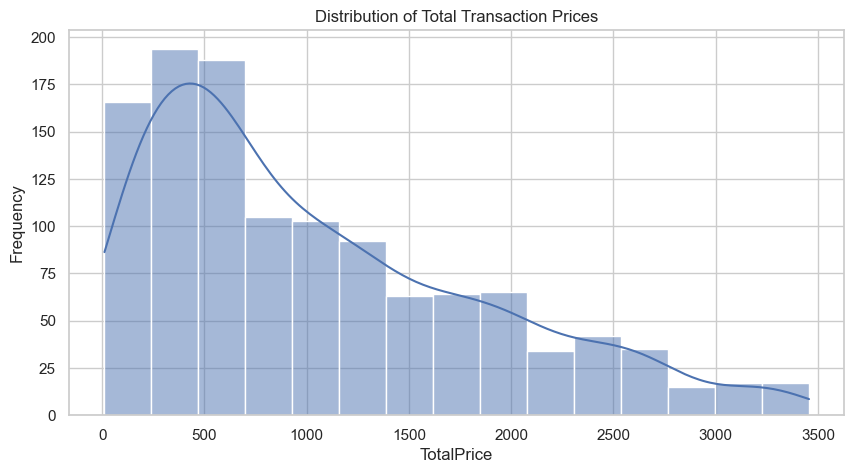


Insight:
The TotalPrice distribution is positively skewed, with most transactions concentrated
in lower and medium price ranges, while a few high-value purchases create a long right tail.



In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(10,5))

sns.histplot(df['TotalPrice'], bins=15, kde=True)

plt.title("Distribution of Total Transaction Prices")
plt.xlabel("TotalPrice")
plt.ylabel("Frequency")

plt.show()
print("""
Insight:
The TotalPrice distribution is positively skewed, with most transactions concentrated
in lower and medium price ranges, while a few high-value purchases create a long right tail.
""")

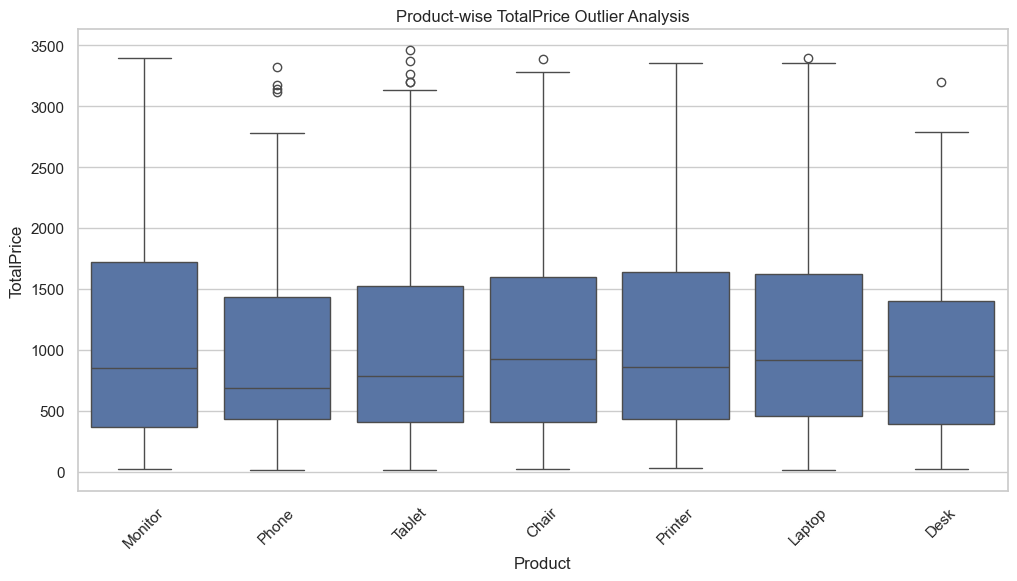


Insight:
Several products contain high-value outliers, indicating rare but expensive transactions
that may represent premium customer purchases or unusual buying behavior.



In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Product', y='TotalPrice', data=df)
plt.title("Product-wise TotalPrice Outlier Analysis")
plt.xlabel("Product")
plt.ylabel("TotalPrice")
plt.xticks(rotation=45)
plt.show()
print("""
Insight:
Several products contain high-value outliers, indicating rare but expensive transactions
that may represent premium customer purchases or unusual buying behavior.
""")

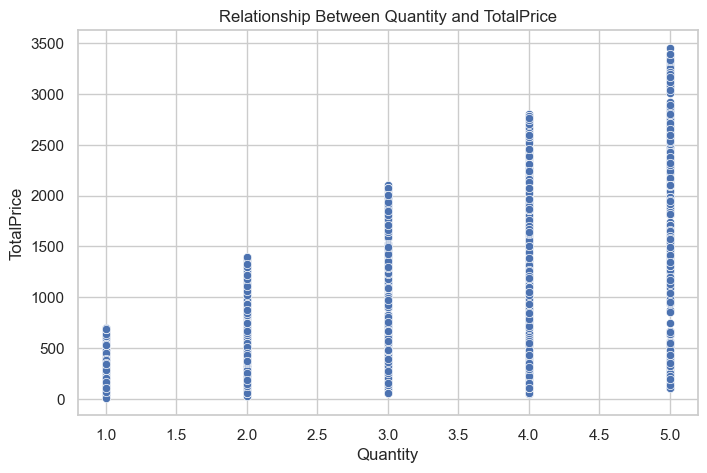


Insight:
A positive relationship exists between Quantity and TotalPrice,
showing that larger purchases generally lead to higher transaction values.



In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Quantity', y='TotalPrice', data=df)

plt.title("Relationship Between Quantity and TotalPrice")
plt.xlabel("Quantity")
plt.ylabel("TotalPrice")

plt.show()
print("""
Insight:
A positive relationship exists between Quantity and TotalPrice,
showing that larger purchases generally lead to higher transaction values.
""")

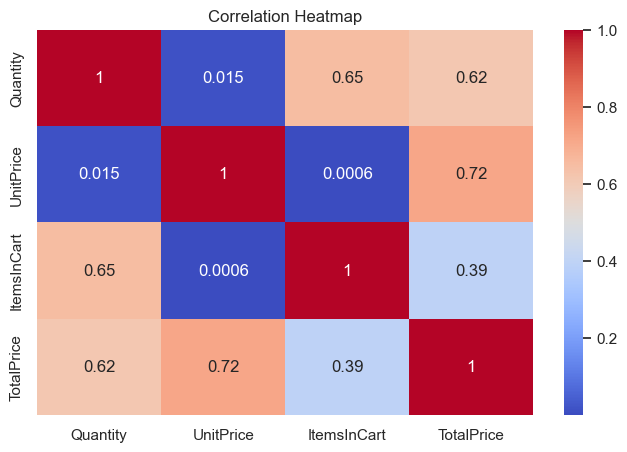

In [13]:
#correlation heat map
numeric_df = df.select_dtypes(include=['int64','float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,5))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

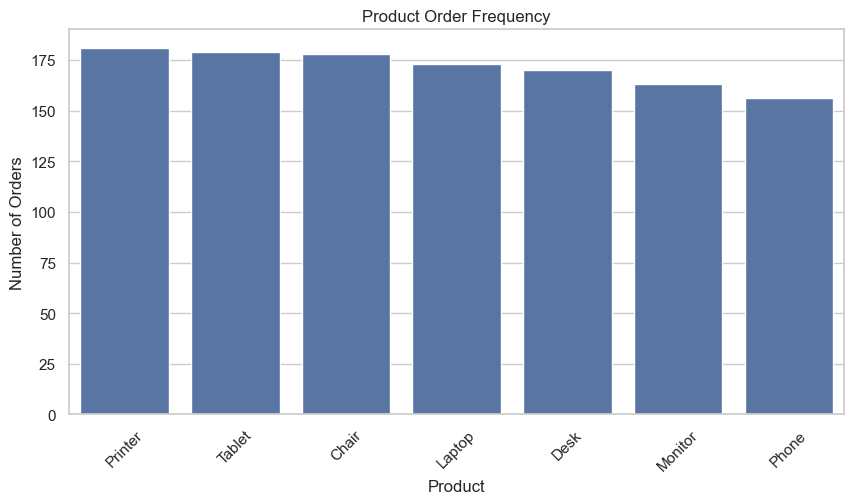


Insight:
Printers and tablets recorded the highest number of orders,
indicating strong customer demand for these products.



In [14]:
plt.figure(figsize=(10,5))

sns.countplot(x='Product',
              data=df,
              order=df['Product'].value_counts().index)

plt.title("Product Order Frequency")
plt.xlabel("Product")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()
print("""
Insight:
Printers and tablets recorded the highest number of orders,
indicating strong customer demand for these products.
""")

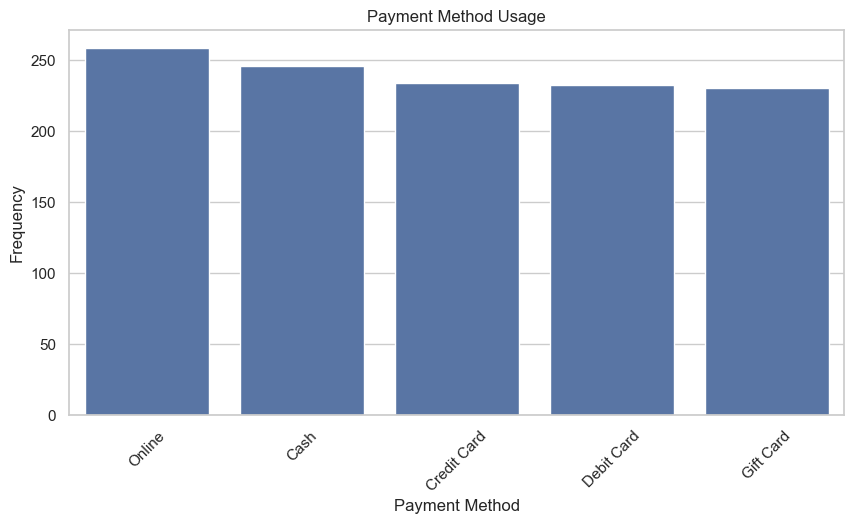


Insight:
Online and cash payments were the most frequently used transaction methods among customers.



In [15]:
plt.figure(figsize=(10,5))

sns.countplot(x='PaymentMethod',
              data=df,
              order=df['PaymentMethod'].value_counts().index)

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()
print("""
Insight:
Online and cash payments were the most frequently used transaction methods among customers.
""")

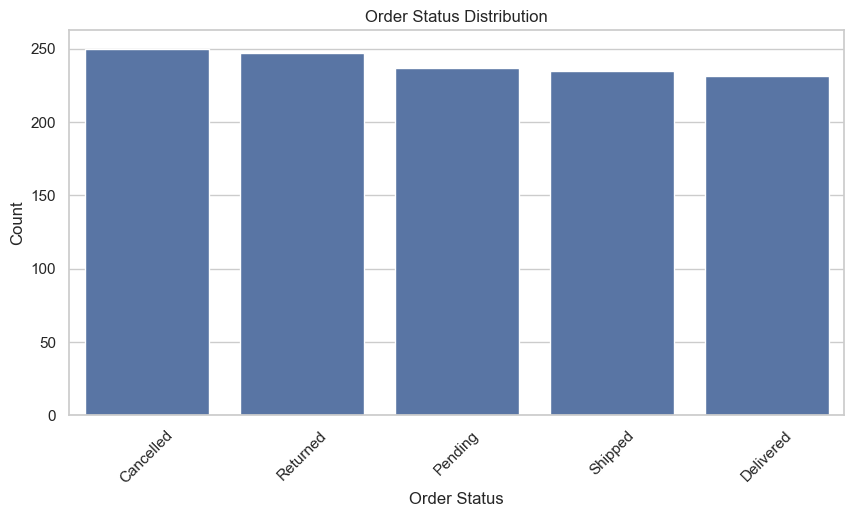


Insight:
Cancelled and returned orders slightly exceeded delivered orders,
which may indicate operational or customer satisfaction issues.



In [16]:
plt.figure(figsize=(10,5))

sns.countplot(x='OrderStatus',
              data=df,
              order=df['OrderStatus'].value_counts().index)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()
print("""
Insight:
Cancelled and returned orders slightly exceeded delivered orders,
which may indicate operational or customer satisfaction issues.
""")

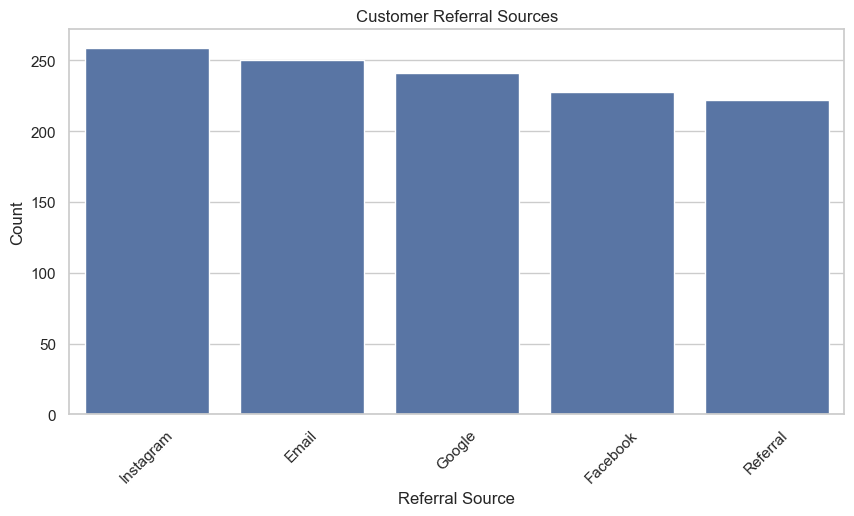


Insight:
Instagram generated the highest number of customer referrals,
making it the strongest acquisition channel in the dataset.



In [17]:
plt.figure(figsize=(10,5))

sns.countplot(x='ReferralSource',
              data=df,
              order=df['ReferralSource'].value_counts().index)

plt.title("Customer Referral Sources")
plt.xlabel("Referral Source")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()
print("""
Insight:
Instagram generated the highest number of customer referrals,
making it the strongest acquisition channel in the dataset.
""")

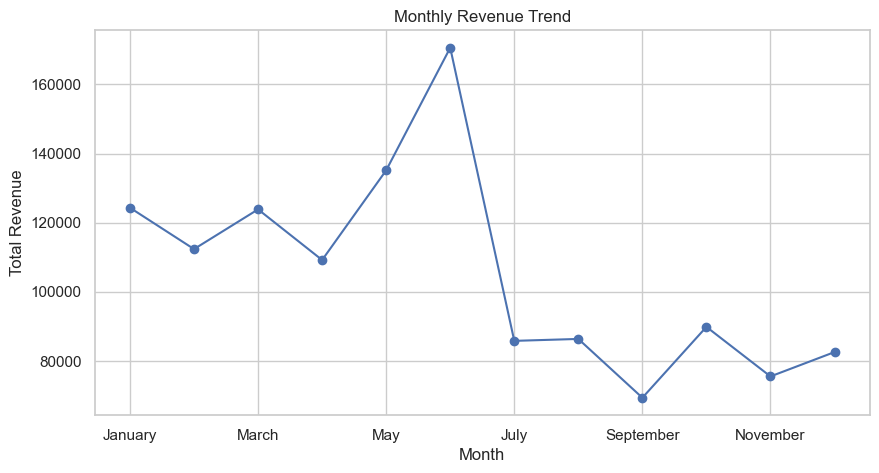


Insight:
Monthly revenue fluctuates throughout the year, with certain months generating
significantly higher sales, suggesting seasonal purchasing behavior.



In [18]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]
df['Month'] = pd.Categorical(
    df['Month'],
    categories=month_order,
    ordered=True
)
monthly_sales = df.groupby('Month',observed=False)['TotalPrice'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.grid(True)

plt.show()
print("""
Insight:
Monthly revenue fluctuates throughout the year, with certain months generating
significantly higher sales, suggesting seasonal purchasing behavior.
""")

business summary

 Final EDA Conclusion

The EDA uncovered key business insights, including skewed transaction values with some high-value outliers, a strong positive relationship between quantity and total price, Instagram as the top referral source, and printers and tablets as the most purchased products. It also highlighted a notable number of cancelled and returned orders, indicating areas for further investigation. Overall, the analysis converted raw transaction data into actionable insights for decision-making.


DASHBOARD

Exploratory Data Analysis Dashboard
E-Commerce Sales Dataset

# Objective
The objective of this project is to analyze customer orders,
sales trends, product performance, and business patterns
using Exploratory Data Analysis (EDA).

# Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

In [19]:
# KPI Metrics
total_revenue = df['TotalPrice'].sum()
total_orders = df['OrderID'].nunique()
avg_order_value = df['TotalPrice'].mean()
top_product = df['Product'].mode()[0]
print("===== KEY PERFORMANCE INDICATORS =====\n")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value: ${avg_order_value:.2f}")
print(f"Most Sold Product: {top_product}")

===== KEY PERFORMANCE INDICATORS =====

Total Revenue: $1,264,761.96
Total Orders: 1200
Average Order Value: $1053.97
Most Sold Product: Printer


In [20]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
